# 01 – LPT basics with `fwd_model_tools`

This notebook demonstrates a basic workflow for working with initial conditions
and Lagrangian Perturbation Theory (LPT):

1. Draw Gaussian initial conditions on a regular mesh.
2. Evolve them with first-order LPT to obtain particle displacements.
3. Paint particles back to a density field and visualize slices.
4. Produce a simple spherical projection of the density field.

All operations use `DensityField`/`ParticleField` objects that carry mesh and box metadata.


## Imports & utility setup
We configure JAX to run on CPU, import the main dependencies, and define a small
mesh/box so the example runs quickly on a laptop.


In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax_cosmo as jc

from fwd_model_tools import (
    FieldStatus,
    ParticleField,
    gaussian_initial_conditions,
    interpolate_initial_conditions,
    lpt,
    Planck18,
)

mesh_size = (128, 128, 128)
box_size = (500.0, 500.0, 500.0)


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


## Draw Gaussian Initial Conditions
We provide a PRNG key, cosmology, and mesh/box metadata to
`gaussian_initial_conditions`. The returned `DensityField` is tagged with
`FieldStatus.INITIAL_FIELD` and carries the mesh and box information.


In [2]:
key = jax.random.PRNGKey(0)
cosmo = Planck18()

gaussian_field = gaussian_initial_conditions(
    key=key,
    cosmo=cosmo,
    mesh_size=mesh_size,
    box_size=box_size,
)

print(gaussian_field)
print(f"Status: {gaussian_field.status} (expected {FieldStatus.INITIAL_FIELD})")
print(f"Array shape: {gaussian_field.array.shape}, dtype: {gaussian_field.array.dtype}")


DensityField(array=Array(128, 128, 128), mesh_size=(128, 128, 128), box_size=(500.0, 500.0, 500.0), status=initial_field, scale_factors_shape=(1,))
Status: FieldStatus.INITIAL_FIELD (expected FieldStatus.INITIAL_FIELD)
Array shape: (128, 128, 128), dtype: float64


## Compute first-order LPT displacements
We apply first-order LPT to convert the Gaussian density field into particle
positions and momenta. This returns `ParticleField` objects with LPT status.


In [3]:
cosmo = Planck18()
initial_scale_factor = 0.5

dx_field, p_field = lpt(
    cosmo=cosmo,
    initial_field=gaussian_field,
    a=initial_scale_factor,
    order=1,
)

print(f"Displacement field: {dx_field}")
print(f"  Status: {dx_field.status} (expected {FieldStatus.LPT1})")
print(f"  Array shape: {dx_field.array.shape} (should be {mesh_size + (3,)})")
print(f"  Scale factors: {dx_field.scale_factors}")

print(f"\nMomentum field: {p_field}")
print(f"  Status: {p_field.status}")
print(f"  Array shape: {p_field.array.shape}")


shape of initial force: (128, 128, 128, 3)
growth factor shape: (1,)
Displacement field: ParticleField(array=Array(128, 128, 128, 3), mesh_size=(128, 128, 128), box_size=(500.0, 500.0, 500.0), status=lpt1, scale_factors_shape=(1,))
  Status: FieldStatus.LPT1 (expected FieldStatus.LPT1)
  Array shape: (128, 128, 128, 3) (should be (128, 128, 128, 3))
  Scale factors: [0.5]

Momentum field: ParticleField(array=Array(128, 128, 128, 3), mesh_size=(128, 128, 128), box_size=(500.0, 500.0, 500.0), status=lpt1, scale_factors_shape=(1,))
  Status: FieldStatus.LPT1
  Array shape: (128, 128, 128, 3)


## Paint to a 3D density field and 2D slice
Using `ParticleField.paint`, we convert displacements back into a gridded
density field. We then inspect a central slice of the resulting 3D density.


DensityField(array=Array(128, 128, 128), mesh_size=(128, 128, 128), box_size=(500.0, 500.0, 500.0), status=density_field, scale_factors_shape=(1,))
Paint status: FieldStatus.DENSITY_FIELD (expected FieldStatus.DENSITY_FIELD)
Density contrast range: [0.000, 22.673]

Recovered displacement field: DensityField(array=Array(128, 128, 128), mesh_size=(128, 128, 128), box_size=(500.0, 500.0, 500.0), status=lpt1, scale_factors_shape=(1,))
Max displacement magnitude: 4.009e+00 Mpc/h


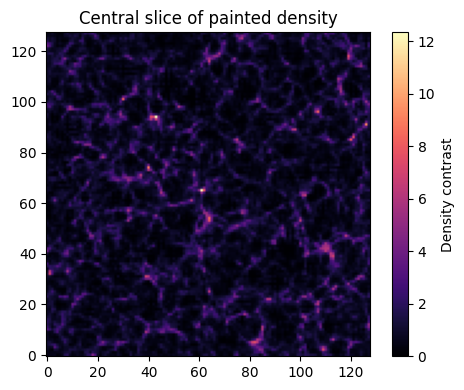

In [4]:
painted_density = dx_field.paint(mode="relative")
print(painted_density)
print(f"Paint status: {painted_density.status} (expected {FieldStatus.DENSITY_FIELD})")
print(f"Density contrast range: [{painted_density.array.min():.3f}, {painted_density.array.max():.3f}]")

recovered_displacements = dx_field.read_out(painted_density, mode="relative")
print(f"\nRecovered displacement field: {recovered_displacements}")
print(f"Max displacement magnitude: {jnp.abs(dx_field.array).max():.3e} Mpc/h")

# Visualize a central 2D slice of the painted density
mid = painted_density.array.shape[0] // 2
plt.figure(figsize=(5, 4))
plt.imshow(jnp.asarray(painted_density.array[mid]), origin="lower", cmap="magma")
plt.colorbar(label="Density contrast")
plt.title("Central slice of painted density")
plt.tight_layout()


## Spherical painting
The same displacement field can also drive HEALPix painting once an `nside`
resolution is specified. This projects particles onto a spherical sky map.


In [11]:
spherical_ready = dx_field.replace(nside=128)

spherical_map = spherical_ready.paint_spherical(
    center=150.0,
    density_plane_width=100.0,
    scheme="rbf_neighbor",
    paint_nside=256,
    kernel_width_arcmin=10.0,
)

print(f"HEALPix pixels: {spherical_map.array.shape}, nside={spherical_map.nside}")
print(f"Density range: [{spherical_map.array.min():.3f}, {spherical_map.array.max():.3f}]")
print(f"Non-zero pixels: {(spherical_map.array != 0).sum()} / {spherical_map.array.size}")


HEALPix pixels: (196608,), nside=128
Density range: [0.000, 0.128]
Non-zero pixels: 196564 / 196608


## Spherical map plot
We can visualize the spherical projection using the `show` helper.


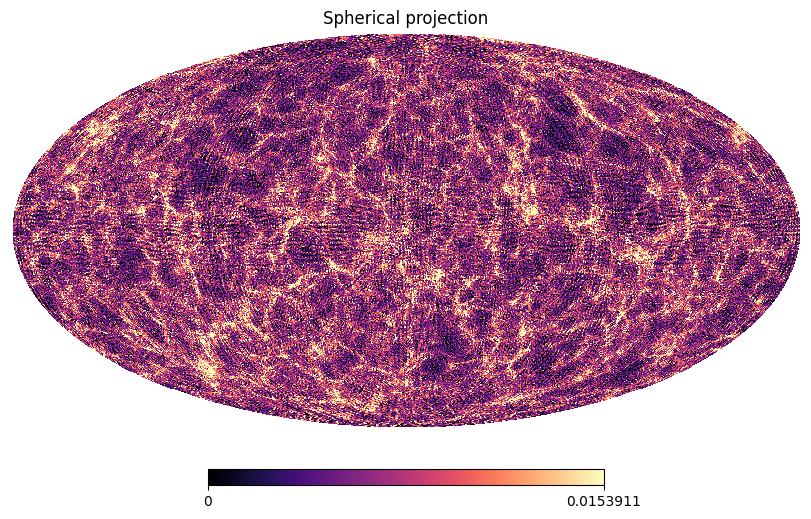

In [12]:
spherical_map.show(figsize=(8, 8), cmap="magma", titles=["Spherical projection"])


## Summary and next steps

In this notebook we:
- sampled Gaussian initial conditions on a regular mesh,
- evolved them with first-order LPT to obtain particle displacements,
- painted those particles back to a density field and inspected a flat slice,
- and produced a simple spherical projection.

In Notebook 02, we will extend this to build an LPT-based lightcone over multiple scale factors.
